In [182]:
import numpy as np
import matplotlib.pyplot as plt
import glob, os
import pandas as pd

import scipy.ndimage
import scienceplots
plt.style.use(['science', 'notebook', 'grid'])

In [183]:
# function to do moving average
def moving_average(x, y, w):
    y = np.convolve(y, np.ones(w), 'valid') / w
    x = x[w-1:]
    return x, y

def crop(x, y, x_min=None, x_max=None):
    if x_min is not None:
        arg_min = x > x_min
        x = x[arg_min]
        y = y[arg_min]
    if x_max is not None:
        arg_max = x < x_max
        x = x[arg_max]
        y = y[arg_max]
    return x, y

In [184]:
folder = "../../build/NewDiode4D/"
files = glob.glob(
    os.path.join(folder, "simulation_history.csv")
)
print(f"Found {len(files)} files.")

Found 1 files.


In [185]:
# csv : time,nb_electrons,nb_holes,nb_impact_ionization,ramo_current_electron,ramo_current_hole,ramo_current,max_electric_field,anode_voltage_V,cathode_voltage_V,quench_bias_voltage_V,quench_device_current_A,quench_resistor_current_A,quench_voltage_drop_V


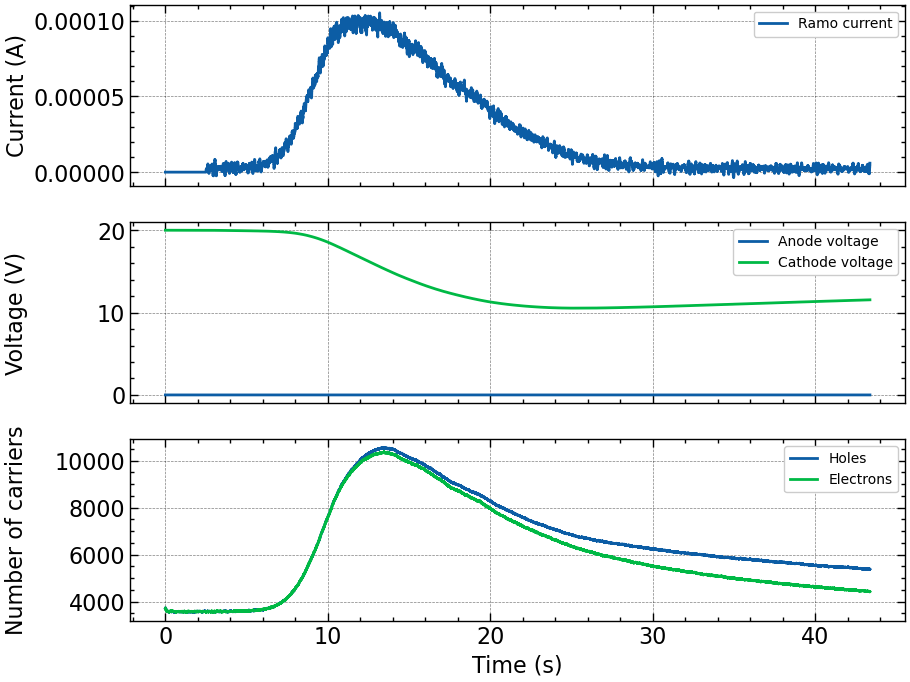

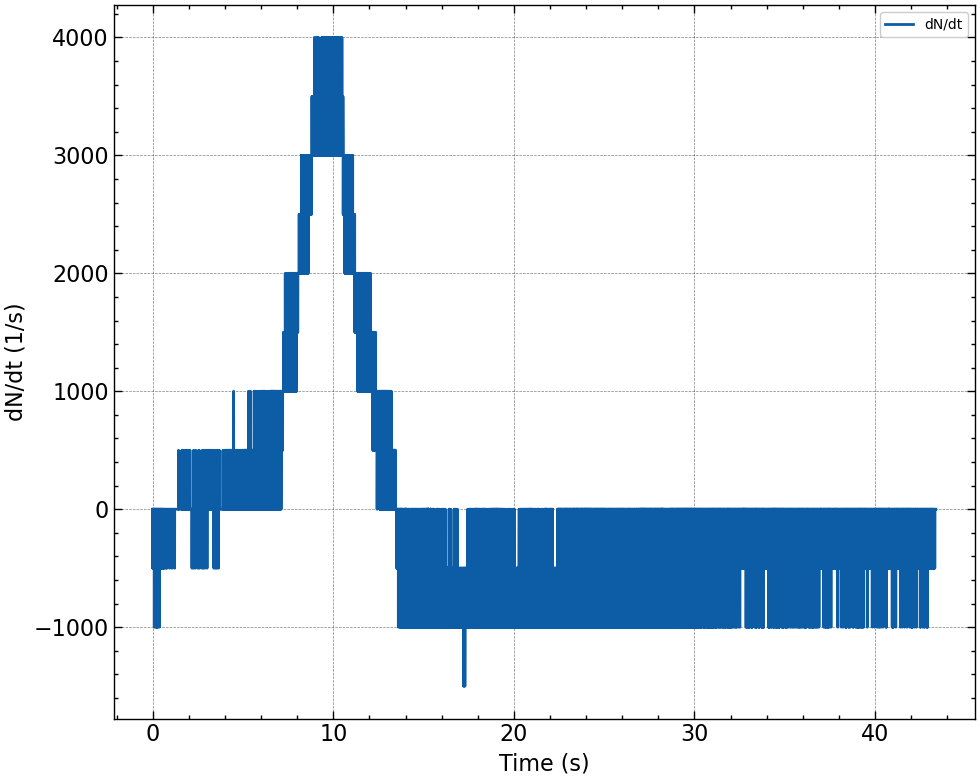

In [186]:
fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
fig2, axs2 = plt.subplots(1, 1, figsize=(10, 8), sharex=True)
Nsmooth = 100
for file in files:
    data = pd.read_csv(file)
    time = data["time"].values * 1e12 # convert to ps
    nb_electrons = data["nb_electrons"].values
    nb_holes = data["nb_holes"].values
    ramo_total_current = data["ramo_current"].values
    anode_voltage = data["anode_voltage_V"].values
    cathode_voltage = data["cathode_voltage_V"].values
    quench_bias_voltage = data["quench_bias_voltage_V"].values
    quench_device_current = data["quench_device_current_A"].values
    quench_voltage_drop = data["quench_voltage_drop_V"].values
    
    tmin = 0.0
    argtmin = time > tmin
    time = time[argtmin]
    nb_electrons = nb_electrons[argtmin]
    nb_holes = nb_holes[argtmin]
    ramo_total_current = ramo_total_current[argtmin]
    anode_voltage = anode_voltage[argtmin]
    cathode_voltage = cathode_voltage[argtmin]
    quench_bias_voltage = quench_bias_voltage[argtmin]
    quench_device_current = quench_device_current[argtmin]
    quench_voltage_drop = quench_voltage_drop[argtmin]
    time_smooth, ramo_total_current_smooth = moving_average(time, ramo_total_current, Nsmooth)

    axs[0].plot(time, quench_device_current, label="Ramo current")
    axs[1].plot(time, anode_voltage, label="Anode voltage")
    axs[1].plot(time, cathode_voltage, label="Cathode voltage")
    axs[2].plot(time, nb_holes, label="Holes")
    axs[2].plot(time, nb_electrons, label="Electrons")
    
    # Diff nb carriers
    sigma = 200
    smooth_nb_electrons = scipy.ndimage.gaussian_filter1d(nb_electrons, sigma=sigma)
    smooth_nb_holes = scipy.ndimage.gaussian_filter1d(nb_holes, sigma=sigma)
    d_nb_carriers_dt = np.gradient(smooth_nb_electrons + smooth_nb_holes, time)
    axs2.plot(time, d_nb_carriers_dt, label="dN/dt")

axs[-1].set_xlabel("Time (s)")
axs[0].set_ylabel("Current (A)")
axs[1].set_ylabel("Voltage (V)")
axs[2].set_ylabel("Number of carriers")
fontsize_ = 10
axs[0].legend(fontsize=fontsize_)
axs[1].legend(fontsize=fontsize_)
axs[2].legend(fontsize=fontsize_)

axs[-1].set_xlim()
fig.align_ylabels()

axs2.set_xlabel("Time (s)")
axs2.set_xlim()
axs2.set_ylabel("dN/dt (1/s)")
axs2.legend(fontsize=fontsize_)

# axs[0].set_ylim(-1e-5, 2e-5)

plt.tight_layout()
plt.show()